In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score


df = pd.read_csv('/content/drive/MyDrive/AIML_lab_sem4/exp 11,12/dataset_Melbourne_housing_FULL_exp_12.csv')



In [18]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  object 
 6   SellerG        34857 non-null  object 
 7   Date           34857 non-null  object 
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  object 
 17  Lattitude      26881 non-null  float64
 18  Longti

In [20]:
df.isnull().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,7610
Method,0
SellerG,0
Date,0
Distance,1
Postcode,1


In [21]:
df = df.dropna(subset=['Price'])

In [22]:
num_cols = ['Rooms', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']
cat_cols = ['Type', 'Method', 'CouncilArea', 'Regionname']

In [23]:
X = df[num_cols + cat_cols]
y = df['Price']

In [24]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [25]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [26]:
df = df.drop(['Address', 'Date'], axis=1)

df = pd.get_dummies(df, drop_first=True)

In [27]:
X = df.drop('Price', axis=1)
y = df['Price']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.metrics import mean_squared_error

# Apply Ridge (L2 Regularization)
ridge = Ridge(alpha=100)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("\nRidge Results:")
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
print("MSE:", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2 Score:", r2_score(y_test, y_pred_ridge))


Ridge Results:
MSE: 148308986100.42667
RMSE: 385109.05741156836
R2 Score: 0.6529238980216601


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Apply Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_train_scaled, y_train)

y_pred_linear = linear_reg.predict(X_test_scaled)

print("\nLinear Regression Results:")
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
print("MSE:", mse_linear)
print("RMSE:", rmse_linear)
print("R2 Score:", r2_score(y_test, y_pred_linear))


Linear Regression Results:
MSE: 152722264764.61996
RMSE: 390796.9610483428
R2 Score: 0.6425958417387105


In [37]:
from sklearn.linear_model import Lasso

# Apply Lasso (L1 Regularization)
lasso = Lasso(alpha=5.0) # You can tune alpha as needed
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("\nLasso Results:")
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
print("MSE:", mse_lasso)
print("RMSE:", rmse_lasso)
print("R2 Score:", r2_score(y_test, y_pred_lasso))


Lasso Results:
MSE: 148275760119.93
RMSE: 385065.91659082216
R2 Score: 0.6530016542257742


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.717e+14, tolerance: 8.882e+11
  model = cd_fast.enet_coordinate_descent(


In [36]:
lasso_coeff = pd.Series(lasso.coef_, index=X.columns)
ridge_coeff = pd.Series(ridge.coef_, index=X.columns)

print("\nNumber of features used by Lasso:", sum(lasso_coeff != 0))
print("Number of features used by Ridge:", len(ridge_coeff))


Number of features used by Lasso: 721
Number of features used by Ridge: 749


/tmp/ipykernel_17265/2865464898.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=r2_scores, palette='viridis')


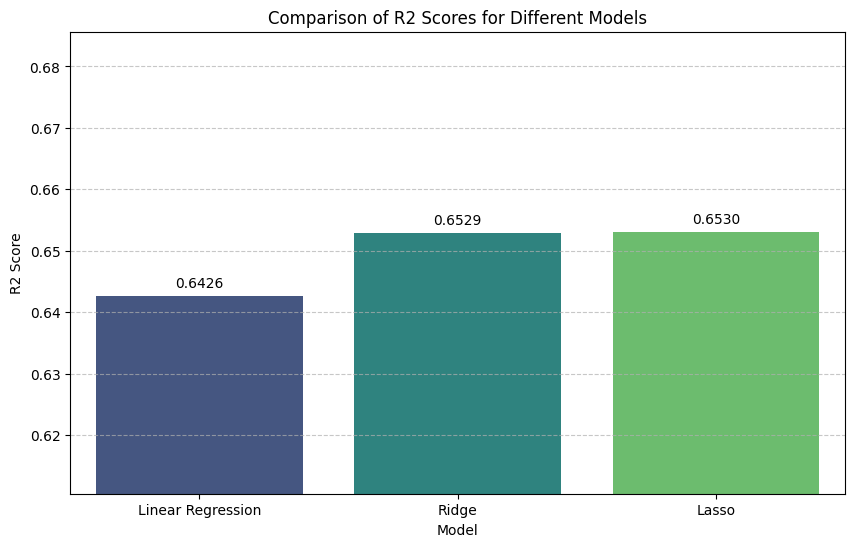

In [41]:
r2_linear = r2_score(y_test, y_pred_linear)
r2_ridge = r2_score(y_test, y_pred_ridge)
r2_lasso = r2_score(y_test, y_pred_lasso)

models = ['Linear Regression', 'Ridge', 'Lasso']
r2_scores = [r2_linear, r2_ridge, r2_lasso]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=models, y=r2_scores, palette='viridis')
plt.title('Comparison of R2 Scores for Different Models')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(min(r2_scores) * 0.95, max(r2_scores) * 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()

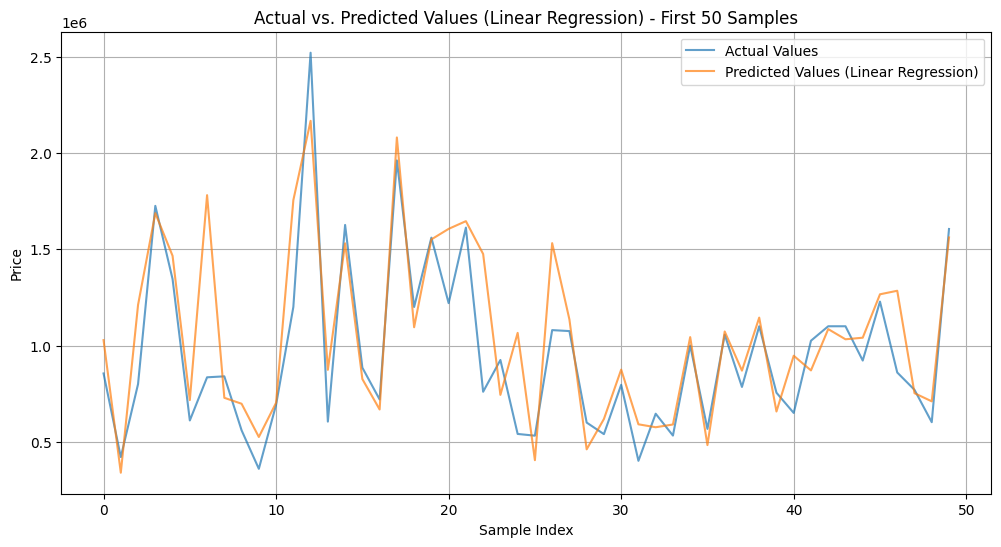

In [43]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Actual Values', alpha=0.7)
plt.plot(y_pred_linear[:50], label='Predicted Values (Linear Regression)', alpha=0.7)
plt.title('Actual vs. Predicted Values (Linear Regression) - First 50 Samples')
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

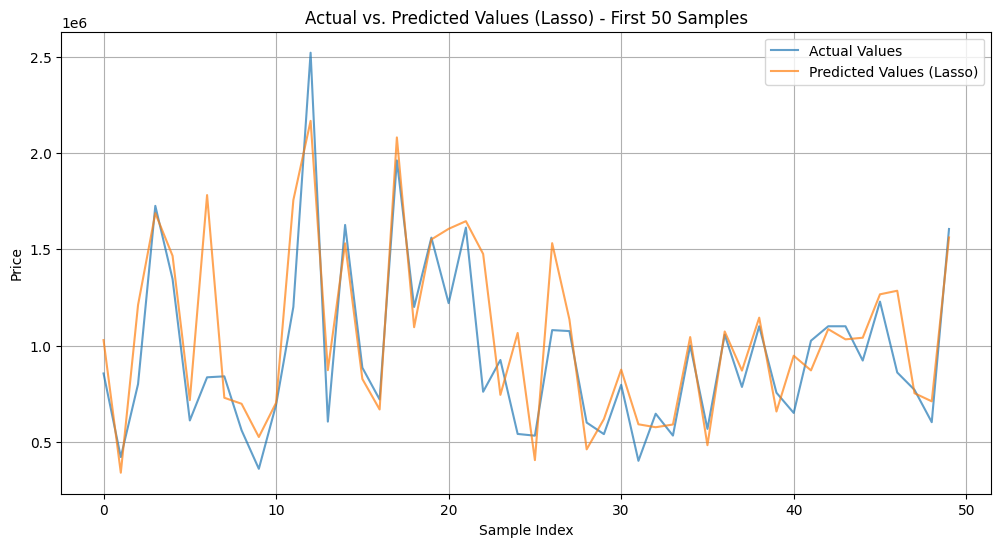

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Actual Values', alpha=0.7)
plt.plot(y_pred_lasso[:50], label='Predicted Values (Lasso)', alpha=0.7)
plt.title('Actual vs. Predicted Values (Lasso) - First 50 Samples')
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

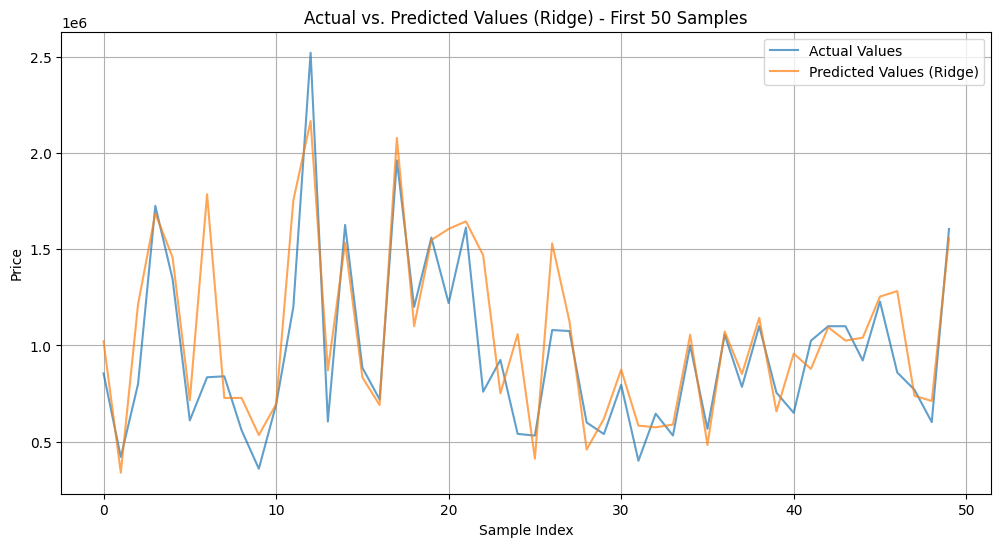

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Actual Values', alpha=0.7)
plt.plot(y_pred_ridge[:50], label='Predicted Values (Ridge)', alpha=0.7)
plt.title('Actual vs. Predicted Values (Ridge) - First 50 Samples')
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
print("\n--- Model Performance Summary ---")
print("\nLinear Regression:")
print(f"  R2 Score: {r2_linear:.4f}")
print(f"  MSE: {mse_linear:.2f}")
print(f"  RMSE: {rmse_linear:.2f}")

print("\nRidge Regression:")
print(f"  R2 Score: {r2_ridge:.4f}")
print(f"  MSE: {mse_ridge:.2f}")
print(f"  RMSE: {rmse_ridge:.2f}")

print("\nLasso Regression:")
print(f"  R2 Score: {r2_lasso:.4f}")
print(f"  MSE: {mse_lasso:.2f}")
print(f"  RMSE: {rmse_lasso:.2f}")


--- Model Performance Summary ---

Linear Regression:
  R2 Score: 0.6426
  MSE: 152722264764.62
  RMSE: 390796.96

Ridge Regression:
  R2 Score: 0.6529
  MSE: 148308986100.43
  RMSE: 385109.06

Lasso Regression:
  R2 Score: 0.6530
  MSE: 148275760119.93
  RMSE: 385065.92


In [47]:
import pickle


lasso_path = "/content/drive/MyDrive/AIML_lab_sem4/exp 11,12/Exp12_models/lasso_model.pkl"
with open(lasso_path, 'wb') as f:
    pickle.dump(lasso, f)

ridge_path = "/content/drive/MyDrive/AIML_lab_sem4/exp 11,12/Exp12_models/ridge_model.pkl"
with open(ridge_path, 'wb') as f:
    pickle.dump(ridge, f)

scaler_path = "/content/drive/MyDrive/AIML_lab_sem4/exp 11,12/Exp12_models/scaler.pkl"
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print("Models and scaler saved successfully!")

Models and scaler saved successfully!
